<a href="https://colab.research.google.com/github/marioguerrerosalah/APRENDIZAJE-NO-SUPERVISADO/blob/main/TALLER_2_NO_SUPERVISADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Cargue del archivo**

In [ ]:
import pandas as pd
from google.colab import drive
## utilizar encoding 1="latin1" para cuando necesito arreglar los datos
drive.mount('/content/drive')
df = pd.read_excel('/content/drive/MyDrive/AP NO SUPERVISADO/EastWestAirlines.xlsx')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [ ]:
df.head()

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [ ]:
df.columns # Para conocer el nombre de las columnas

Index(['ID', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award'],
      dtype='object')

In [ ]:
df_cat= df[['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award']]



In [ ]:
df_cat.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


##Instalación de librerías

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## Exploración preliminar de las variables

Matriz de correlaciones

In [ ]:
corr_matrix = df_cat.corr()
corr_matrix

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
Balance,1.000000,0.108722,0.338344,-0.008804,0.035243,0.403487,0.324935,0.217551,0.255700,0.263129,0.178494
Qual_miles,0.108722,1.000000,0.007931,-0.013923,-0.007779,0.031021,0.050725,0.126774,0.144004,0.017312,0.095256
cc1_miles,0.338344,0.007931,1.000000,-0.068223,0.060555,0.825200,0.608943,0.037370,0.041333,0.230849,0.335457
cc2_miles,-0.008804,-0.013923,-0.068223,1.000000,-0.006166,-0.003969,0.064399,0.010598,0.028284,-0.005807,0.005332
cc3_miles,0.035243,-0.007779,0.060555,-0.006166,1.000000,0.204134,0.097313,-0.001777,-0.001117,0.010832,0.023484
Bonus_miles,0.403487,0.031021,0.825200,-0.003969,0.204134,1.000000,0.603180,0.183536,0.185261,0.210397,0.373506
Bonus_trans,0.324935,0.050725,0.608943,0.064399,0.097313,0.603180,1.000000,0.377216,0.432364,0.161262,0.333893
Flight_miles_12mo,0.217551,0.126774,0.037370,0.010598,-0.001777,0.183536,0.377216,1.000000,0.869193,0.037271,0.217715
Flight_trans_12,0.255700,0.144004,0.041333,0.028284,-0.001117,0.185261,0.432364,0.869193,1.000000,0.059260,0.247909
Days_since_enroll,0.263129,0.017312,0.230849,-0.005807,0.010832,0.210397,0.161262,0.037271,0.059260,1.000000,0.188121


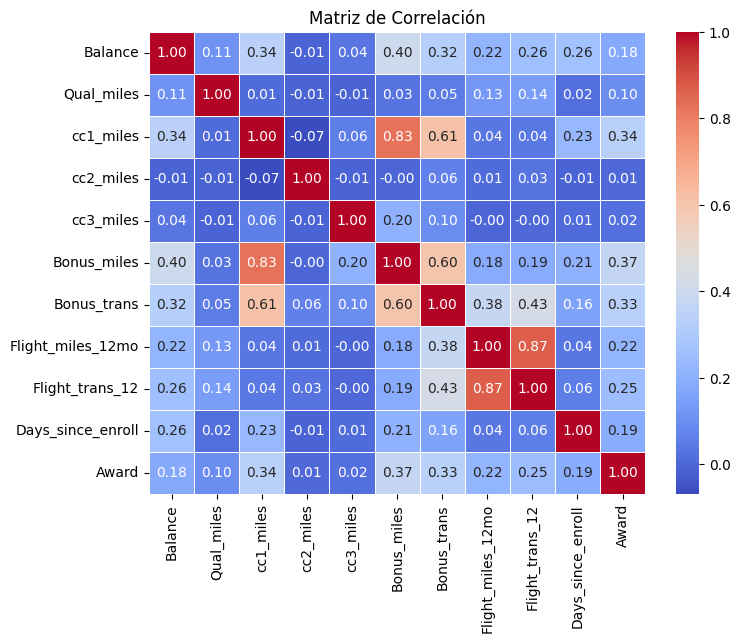

In [ ]:
plt.figure(figsize=(8,6))  # Ajusta el tamaño del gráfico
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

Eliminoi bonus miles pq puede ser redundate ya que este valor se puede derivar de la tarjeta qiur tega la peronas. Se pdria asumir que a medida de que las perosnas tengan una mejor tarjeta van a tener mas puntos. Tambien elimino Flight_trans_12 pq ouede ser redundante con Flight_miles_12mo y siento que esta segunda es mas relevante.

In [ ]:
df_cat= df[['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
            'Bonus_trans', 'Flight_miles_12mo', 'Days_since_enroll', 'Award']]


In [ ]:
corr_matrix = df_cat.corr()
corr_matrix

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_trans,Flight_miles_12mo,Days_since_enroll,Award
Balance,1.000000,0.108722,0.338344,-0.008804,0.035243,0.324935,0.217551,0.263129,0.178494
Qual_miles,0.108722,1.000000,0.007931,-0.013923,-0.007779,0.050725,0.126774,0.017312,0.095256
cc1_miles,0.338344,0.007931,1.000000,-0.068223,0.060555,0.608943,0.037370,0.230849,0.335457
cc2_miles,-0.008804,-0.013923,-0.068223,1.000000,-0.006166,0.064399,0.010598,-0.005807,0.005332
cc3_miles,0.035243,-0.007779,0.060555,-0.006166,1.000000,0.097313,-0.001777,0.010832,0.023484
Bonus_trans,0.324935,0.050725,0.608943,0.064399,0.097313,1.000000,0.377216,0.161262,0.333893
Flight_miles_12mo,0.217551,0.126774,0.037370,0.010598,-0.001777,0.377216,1.000000,0.037271,0.217715
Days_since_enroll,0.263129,0.017312,0.230849,-0.005807,0.010832,0.161262,0.037271,1.000000,0.188121
Award,0.178494,0.095256,0.335457,0.005332,0.023484,0.333893,0.217715,0.188121,1.000000


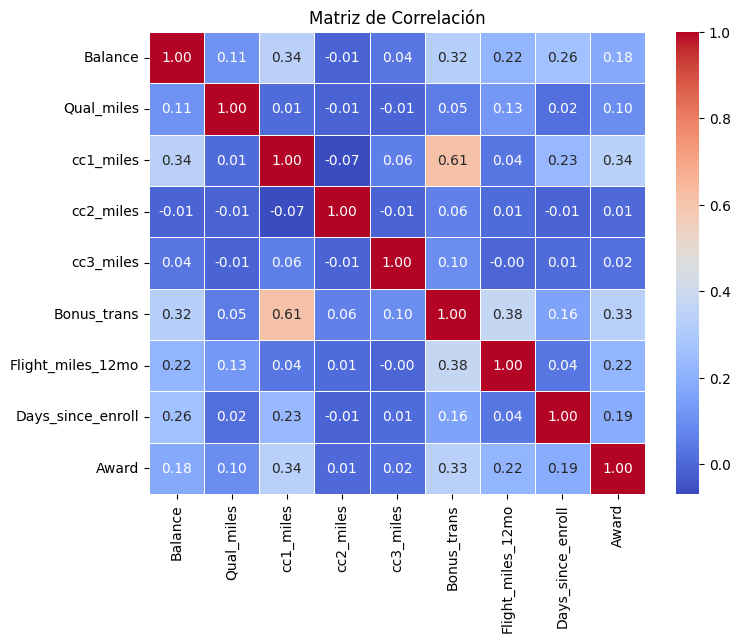

In [ ]:
plt.figure(figsize=(8,6))  # Ajusta el tamaño del gráfico
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

QUITO CC1

In [ ]:
df_cat= df[['Balance', 'Qual_miles', 'cc2_miles', 'cc3_miles',
            'Bonus_trans', 'Flight_miles_12mo', 'Days_since_enroll', 'Award']]


In [ ]:
corr_matrix = df_cat.corr()
corr_matrix

,Balance,Qual_miles,cc2_miles,cc3_miles,Bonus_trans,Flight_miles_12mo,Days_since_enroll,Award
Balance,1.000000,0.108722,-0.008804,0.035243,0.324935,0.217551,0.263129,0.178494
Qual_miles,0.108722,1.000000,-0.013923,-0.007779,0.050725,0.126774,0.017312,0.095256
cc2_miles,-0.008804,-0.013923,1.000000,-0.006166,0.064399,0.010598,-0.005807,0.005332
cc3_miles,0.035243,-0.007779,-0.006166,1.000000,0.097313,-0.001777,0.010832,0.023484
Bonus_trans,0.324935,0.050725,0.064399,0.097313,1.000000,0.377216,0.161262,0.333893
Flight_miles_12mo,0.217551,0.126774,0.010598,-0.001777,0.377216,1.000000,0.037271,0.217715
Days_since_enroll,0.263129,0.017312,-0.005807,0.010832,0.161262,0.037271,1.000000,0.188121
Award,0.178494,0.095256,0.005332,0.023484,0.333893,0.217715,0.188121,1.000000


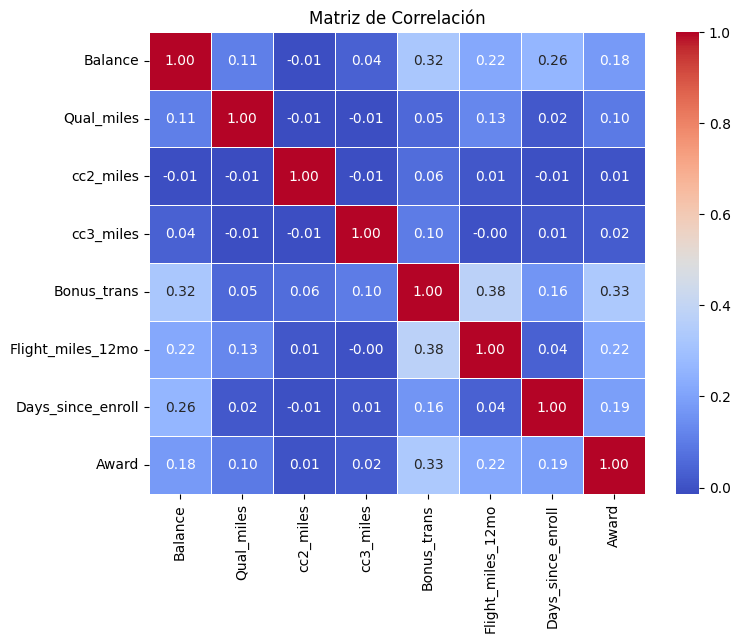

In [ ]:
plt.figure(figsize=(8,6))  # Ajusta el tamaño del gráfico
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

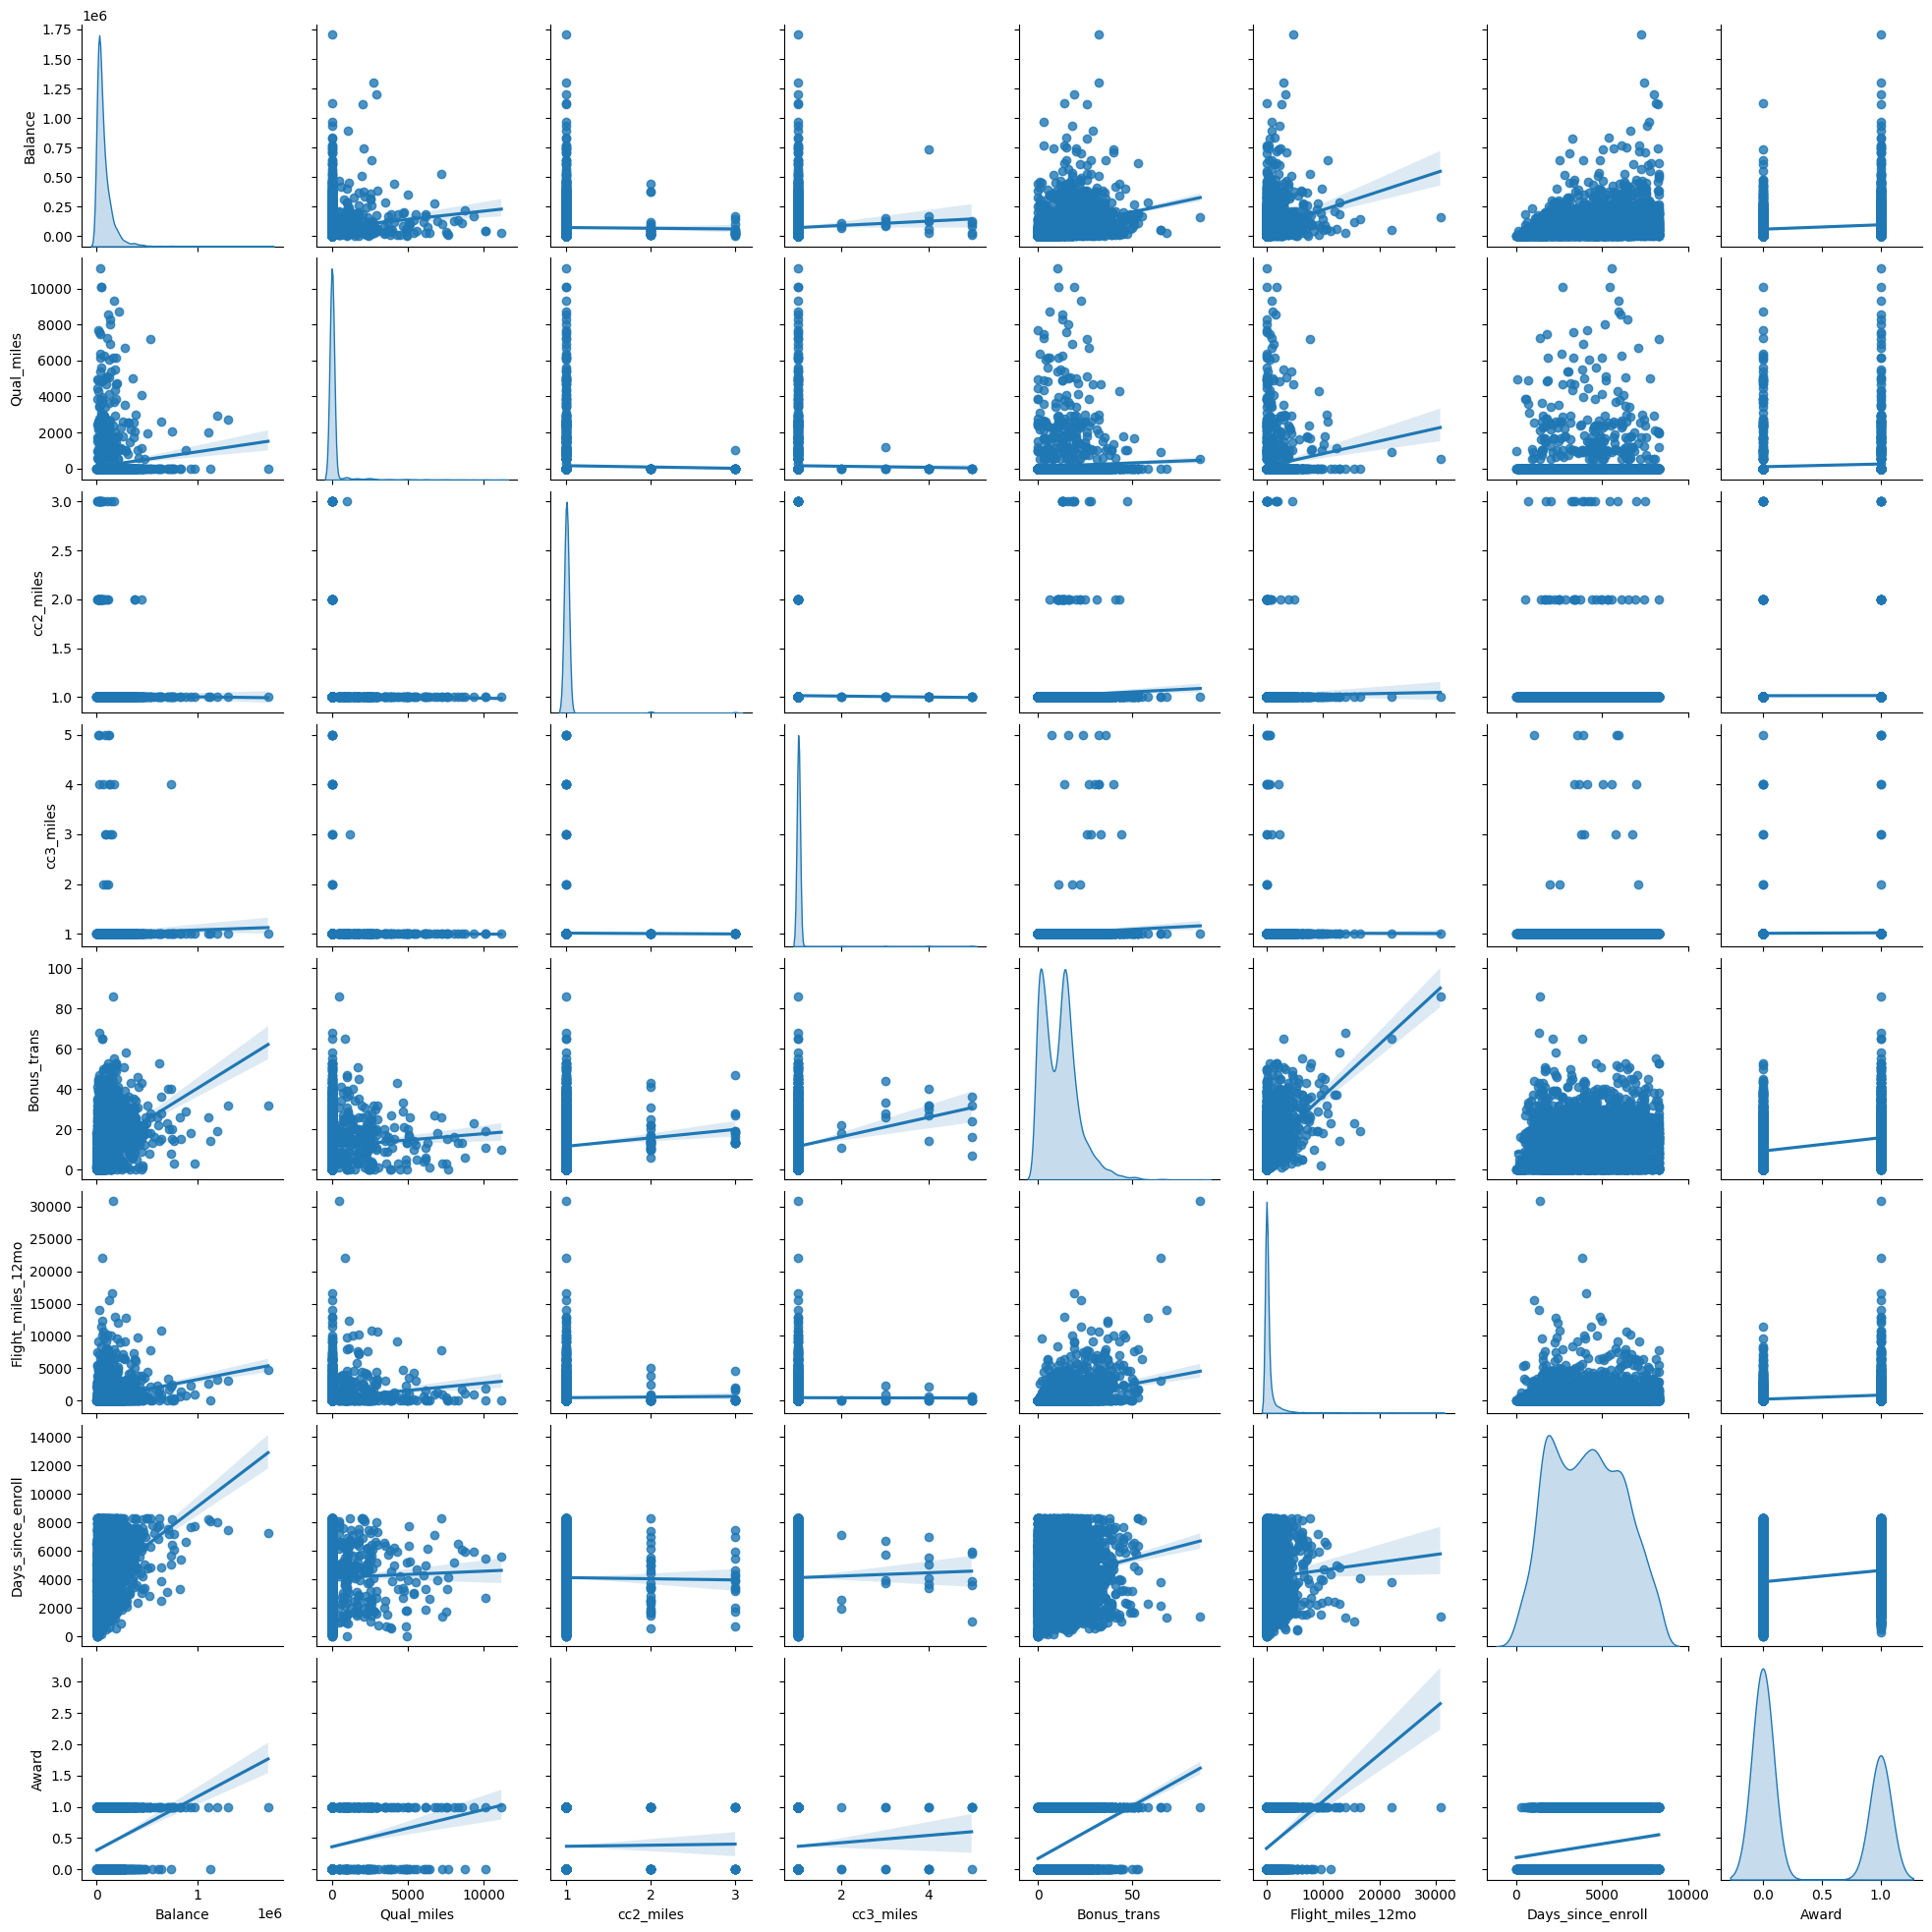

In [ ]:
sns.pairplot(df_cat, kind="reg", diag_kind="kde")
plt.show()

QUITO CC3



In [ ]:
df_cat= df[['Balance', 'Qual_miles', 'cc2_miles', 'Bonus_trans',
            'Flight_miles_12mo', 'Days_since_enroll', 'Award']]


In [ ]:
corr_matrix = df_cat.corr()
corr_matrix

,Balance,Qual_miles,cc2_miles,Bonus_trans,Flight_miles_12mo,Days_since_enroll,Award
Balance,1.000000,0.108722,-0.008804,0.324935,0.217551,0.263129,0.178494
Qual_miles,0.108722,1.000000,-0.013923,0.050725,0.126774,0.017312,0.095256
cc2_miles,-0.008804,-0.013923,1.000000,0.064399,0.010598,-0.005807,0.005332
Bonus_trans,0.324935,0.050725,0.064399,1.000000,0.377216,0.161262,0.333893
Flight_miles_12mo,0.217551,0.126774,0.010598,0.377216,1.000000,0.037271,0.217715
Days_since_enroll,0.263129,0.017312,-0.005807,0.161262,0.037271,1.000000,0.188121
Award,0.178494,0.095256,0.005332,0.333893,0.217715,0.188121,1.000000


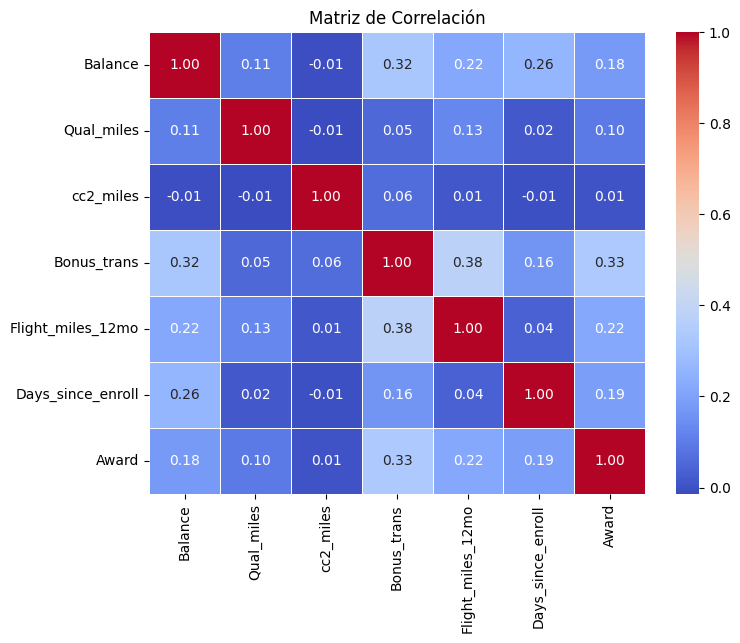

In [ ]:
plt.figure(figsize=(8,6))  # Ajusta el tamaño del gráfico
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cat)
scaled_features

array([[-4.51140783e-01, -1.86298687e-01, -9.82418871e-02, ...,
        -3.28603258e-01,  1.39545434e+00, -7.66919299e-01],
       [-5.39456874e-01, -1.86298687e-01, -9.82418871e-02, ...,
        -3.28603258e-01,  1.37995704e+00, -7.66919299e-01],
       [-3.20031232e-01, -1.86298687e-01, -9.82418871e-02, ...,
        -3.28603258e-01,  1.41192021e+00, -7.66919299e-01],
       ...,
       [-4.29480975e-05, -1.86298687e-01, -9.82418871e-02, ...,
        -3.28603258e-01, -1.31560393e+00,  1.30391816e+00],
       [-1.85606976e-01, -1.86298687e-01, -9.82418871e-02, ...,
         2.85309024e-02, -1.31608822e+00, -7.66919299e-01],
       [-7.00507951e-01, -1.86298687e-01, -9.82418871e-02, ...,
        -3.28603258e-01, -1.31754109e+00, -7.66919299e-01]])

In [ ]:
est=pd.DataFrame(scaled_features, columns=df_cat.columns)
est

,Balance,Qual_miles,cc2_miles,Bonus_trans,Flight_miles_12mo,Days_since_enroll,Award
0,-0.451141,-0.186299,-0.098242,-1.104065,-0.328603,1.395454,-0.766919
1,-0.539457,-0.186299,-0.098242,-0.999926,-0.328603,1.379957,-0.766919
2,-0.320031,-0.186299,-0.098242,-0.791649,-0.328603,1.411920,-0.766919
3,-0.583799,-0.186299,-0.098242,-1.104065,-0.328603,1.372208,-0.766919
4,0.239678,-0.186299,-0.098242,1.499394,1.154932,1.363975,1.303918
...,...,...,...,...,...,...,...
3994,-0.547079,-0.186299,-0.098242,-0.791649,-0.185750,-1.315120,1.303918
3995,-0.091465,-0.186299,-0.098242,-0.687511,-0.328603,-1.318994,1.303918
3996,-0.000043,-0.186299,-0.098242,-0.375096,-0.328603,-1.315604,1.303918
3997,-0.185607,-0.186299,-0.098242,-1.104065,0.028531,-1.316088,-0.766919


## Número de clusters a crear

# Kmeans

Se crea crea el modelo de kmeans

In [ ]:
kmeans = KMeans(
  init="random", # Este parámetro determina donde se ubican los centroides inicialmente
  n_clusters=5, # Corresponde al número de clusters que se van a crear
  n_init=10, # El número de veces que se iniciarán los centroides para seleccionar los mejores, según la inercia
  max_iter=300, # Número máximo de iteraciones para encontrar los clusters optimos
  random_state=42 # Este valor asegura que los resultados son reproducibles
  )

Ajuste del modelo

In [ ]:
kmeans.fit(scaled_features)

KMeans(init='random', n_clusters=5, n_init=10, random_state=42)

In [ ]:
kmeans.inertia_ # es la medida de la suma de las distancias al cuadrado entre cada punto y el centroide.
# Entre menor sea este valor, generalmente indica una mejor clusterización.
# Pero esta no debería ser la medida que determina el número de clusters.

14586.528720984807

In [ ]:
kmeans.cluster_centers_ # Muestra los centroides de los clusters

array([[-3.60873407e-01, -1.28938363e-01, -9.82418871e-02,
        -4.82871697e-01, -2.04297792e-01, -9.23620219e-01,
        -7.54340180e-01],
       [ 7.74744915e-02, -1.48925681e-01, -9.82418871e-02,
        -4.16705573e-02, -1.88184372e-01,  7.49981752e-01,
        -7.66919299e-01],
       [ 1.94714645e+00,  2.56978606e+00, -9.82418871e-02,
         1.25355965e+00,  2.59504140e+00,  3.59496073e-01,
         8.28643989e-01],
       [-4.68896637e-02, -1.56235600e-01,  9.03825361e+00,
         6.17851143e-01,  8.75493989e-02, -7.24639805e-02,
         5.17838824e-02],
       [ 2.48007687e-02, -9.41987981e-02, -9.82418871e-02,
         3.24830886e-01,  3.74861402e-03,  2.27018846e-01,
         1.30234457e+00]])

Los centroides estan estandarizados por lo tanto los queremos en su formato original

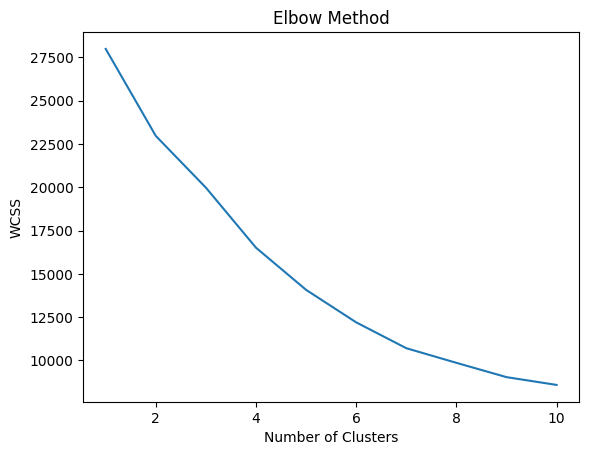

In [ ]:
wcss = [] # crear una lista para almacenar los valores de WCSS

# Calcular el WCSS para diferentes valores de k
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Gráfico del codo
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
standardized_centroids = kmeans.cluster_centers_

original_centroids = scaler.inverse_transform(standardized_centroids)
original_centroids

array([[ 3.72386173e+04,  4.43720577e+01,  1.00000000e+00,
         6.96507213e+00,  1.74031891e+02,  2.21139787e+03,
         6.07441154e-03],
       [ 8.14078947e+04,  2.89105263e+01,  1.00000000e+00,
         1.12017544e+01,  1.96591228e+02,  5.66717895e+03,
        -5.44009282e-15],
       [ 2.69801770e+05,  2.13201639e+03,  1.00000000e+00,
         2.36393443e+01,  4.09320219e+03,  4.86087432e+03,
         7.70491803e-01],
       [ 6.88765814e+04,  2.32558140e+01,  2.34883721e+00,
         1.75348837e+01,  5.82627907e+02,  3.96893023e+03,
         3.95348837e-01],
       [ 7.61003290e+04,  7.12454407e+01,  1.00000000e+00,
         1.47211246e+01,  4.65303951e+02,  4.58732523e+03,
         9.99240122e-01]])

Ya tenemos un modelo que nos crea un número determinado de clusters. Ahora necesitamos saber cada registro en que cluster quedó asignado

In [ ]:
labels = kmeans.predict(scaled_features)
df['cluster'] = labels
df

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award,cluster
0,1,28143,0,1,1,1,174,1,0,0,7000,0,1
1,2,19244,0,1,1,1,215,2,0,0,6968,0,1
2,3,41354,0,1,1,1,4123,4,0,0,7034,0,1
3,4,14776,0,1,1,1,500,1,0,0,6952,0,1
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1,4
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1,4
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1,4
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0,0


## Conteo de Clientes por Cluster

Aquí se muestra la distribución de clientes en cada cluster:

In [ ]:
client_counts = df['cluster'].value_counts().sort_index()
display(client_counts.to_frame(name='Número de Clientes'))

,Número de Clientes
cluster,
0,1318
1,1139
2,183
3,43
4,1316


In [ ]:
cluster_profiles = pd.DataFrame(original_centroids, columns=df_cat.columns)
cluster_profiles.index.name = 'Cluster'
cluster_profiles = cluster_profiles.round(2)

for i, row in cluster_profiles.iterrows():
    print(f"### Cluster {i}:\n")
    print(f"*   **Balance (Saldo de Millas):** {row['Balance']:.2f} (promedio)\n")
    print(f"*   **Qual_miles (Millas Calificadas):** {row['Qual_miles']:.2f} (promedio)\n")
    print(f"*   **cc2_miles (Millas por Tarjeta de Crédito CC2):** {row['cc2_miles']:.2f} (promedio)\n")
    print(f"*   **Bonus_trans (Transacciones de Bonificación):** {row['Bonus_trans']:.2f} (promedio)\n")
    print(f"*   **Flight_miles_12mo (Millas de Vuelo en los últimos 12 meses):** {row['Flight_miles_12mo']:.2f} (promedio)\n")
    print(f"*   **Days_since_enroll (Días desde la inscripción):** {row['Days_since_enroll']:.2f} (promedio)\n")
    print(f"*   **Award (Millas de Premio Redimidas):** {row['Award']:.2f} (promedio)\n")

    print("#### Implicaciones de Negocio y Estrategias:\n")
    if i == 0:
        print("**Descripción:** Este cluster representa clientes con un balance moderado, pocas millas calificadas y de vuelo, y una antigüedad media en el programa. Su número de transacciones de bonificación es también medio. Tienen una probabilidad moderada de haber redimido premios.\n")
        print("**Implicaciones:** Un segmento sólido pero no de élite. Podrían tener potencial para aumentar su engagement si se les incentiva correctamente.\n")
        print("**Estrategias:** Ofrecer promociones personalizadas para aumentar las transacciones y vuelos. Campañas de email marketing con ofertas de upgrades o beneficios por lealtad.")
    elif i == 1:
        print("**Descripción:** Este cluster se caracteriza por un balance de millas bajo, muy pocas millas calificadas y de vuelo, y la menor cantidad de transacciones de bonificación. Son clientes con una antigüedad media en el programa y muy baja probabilidad de haber redimido premios. Es el cluster más grande en número de clientes.\n")
        print("**Implicaciones:** Son la base de clientes, pero también los menos comprometidos. Existe una gran oportunidad para convertirlos en clientes más activos.\n")
        print("**Estrategias:** Programas de bienvenida y reactivación. Incentivar con bonos por primera compra o por referidos. Educar sobre los beneficios del programa de fidelidad.")
    elif i == 2:
        print("**Descripción:** Clientes con un balance muy alto de millas, una cantidad significativamente alta de millas calificadas, y un elevado número de transacciones de bonificación y millas de vuelo. Son clientes muy antiguos en el programa y tienen una alta probabilidad de haber redimido premios. Este es el cluster más pequeño.\n")
        print("**Implicaciones:** Estos son los clientes 'VIP' o de alto valor. Son extremadamente leales y activos. Su retención y satisfacción son cruciales.\n")
        print("**Estrategias:** Programas de reconocimiento exclusivo, atención al cliente prioritaria, ofertas personalizadas para sus destinos preferidos y acceso a eventos exclusivos.")
    elif i == 3:
        print("**Descripción:** Clientes con un balance alto, aunque no tan extremo como el Cluster 2. Tienen millas calificadas moderadas, una cantidad respetable de transacciones de bonificación y millas de vuelo. Llevan bastante tiempo inscritos y tienen una probabilidad muy alta de haber redimido premios.\n")
        print("**Implicaciones:** Clientes valiosos y comprometidos que ya utilizan activamente el programa. Es vital mantener su engagement y lealtad.\n")
        print("**Estrategias:** Comunicación continua sobre nuevos beneficios, encuestas de satisfacción para anticipar necesidades, y ofertas de experiencias premium. Promocionar el uso de tarjetas CC3 si no las tienen ya.")
    elif i == 4:
        print("**Descripción:** Clientes con un balance medio, pero con un número considerable de millas de vuelo y transacciones de bonificación. Tienen una antigüedad muy alta en el programa y una alta probabilidad de haber redimido premios. Destaca que tienen un mayor promedio de millas por tarjeta de crédito CC2.\n")
        print("**Implicaciones:** Son clientes leales a largo plazo, posiblemente viajeros frecuentes que valoran los beneficios de la tarjeta CC2. Son importantes para la sostenibilidad del programa.\n")
        print("**Estrategias:** Enfocarse en mantener la satisfacción a través de un servicio consistente y beneficios tangibles. Ofrecerles opciones para maximizar el valor de sus millas acumuladas a través de su CC2. Explorar oportunidades de upsell a tarjetas CC3.")
    print("\n---\n")

### Cluster 0:

*   **Balance (Saldo de Millas):** 37238.62 (promedio)

*   **Qual_miles (Millas Calificadas):** 44.37 (promedio)

*   **cc2_miles (Millas por Tarjeta de Crédito CC2):** 1.00 (promedio)

*   **Bonus_trans (Transacciones de Bonificación):** 6.97 (promedio)

*   **Flight_miles_12mo (Millas de Vuelo en los últimos 12 meses):** 174.03 (promedio)

*   **Days_since_enroll (Días desde la inscripción):** 2211.40 (promedio)

*   **Award (Millas de Premio Redimidas):** 0.01 (promedio)

#### Implicaciones de Negocio y Estrategias:

**Descripción:** Este cluster representa clientes con un balance moderado, pocas millas calificadas y de vuelo, y una antigüedad media en el programa. Su número de transacciones de bonificación es también medio. Tienen una probabilidad moderada de haber redimido premios.

**Implicaciones:** Un segmento sólido pero no de élite. Podrían tener potencial para aumentar su engagement si se les incentiva correctamente.

**Estrategias:** Ofrecer promociones per